# Profile: desk, monthly

The second profile is a **professional desk rebalancing monthly**. The trade-offs invert the
[retail profile](01_Profile_Retail_Daily.md): rebalancing infrequently means each decision can
afford real compute and real analysis, and turnover matters far less. The edge here comes from a
*view* and from exploring the whole risk/return trade-off rather than from cost control.

The reasoning, following the [strategy decision framework](../../user_guide/06_Choosing_a_Strategy.md):

  - **Compute is abundant, decisions are rare** — a monthly cadence justifies a richer prior and a
    full frontier sweep.
  - **The desk has a view** — it encodes a house thesis with an `EntropyPoolingPrior`
    rather than taking the sample moments at face value.
  - **Explore, then choose** — instead of one objective, it traces the efficient frontier and
    selects the risk-adjusted (tangency) book.
  - **Budget is substantial** — an exact `DiscreteAllocation` is affordable.

> **When to reach for this**
>
> This is the template for a research-driven, lower-frequency book: invest the compute in a
> better prior and a frontier sweep, pick a point deliberately, and allocate exactly. Turnover
> and fee control matter less when you trade rarely.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, Clarabel, HiGHS,
      StatsPlots, GraphRecipes

resfmt = (v, i, j) -> begin
    return if j == 1
        v
    else
        isa(v, AbstractFloat) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. Data and the house view

The desk's thesis: healthcare will outperform energy. It encodes that as an entropy-pooling view,
reweighting the empirical scenarios so the prior reflects the conviction (see
[Entropy Pooling](../2_moments_priors/07_Entropy_Pooling.md)).

In [2]:
X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
prices = vec(values(X)[end, :])

sets = AssetSets(;
                 dict = Dict("nx" => rd.nx, "energy" => ["CVX", "XOM", "RRC"],
                             "healthcare" => ["JNJ", "LLY", "MRK", "PFE", "UNH"]))
view_prior = EntropyPoolingPrior(; sets = sets,
                                 mu_views = LinearConstraintEstimator(;
                                                                      val = ["healthcare >= energy"]))
pr = prior(view_prior, rd)

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
rf = 4.2 / 100 / 252

0.0001666666666666667

## 2. The efficient frontier

With compute to spare, the desk traces the whole frontier on the view-tilted prior — minimum-risk
books across a sweep of return targets — rather than committing to a single objective up front.

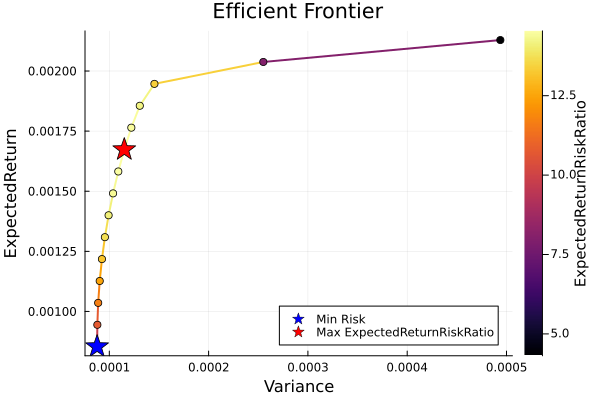

In [3]:
frontier = optimise(MeanRisk(; obj = MinimumRisk(),
                             opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                 ret = ArithmeticReturn(;
                                                                        lb = Frontier(;
                                                                                      N = 15)))))

plot_efficient_frontier(frontier.w, pr; rt = frontier.ret)

## 3. Choosing the book

From the frontier, the desk takes the risk-adjusted optimum — the `MaximumRatio`
(tangency) portfolio on the same view-tilted prior.

In [4]:
desk = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                         opt = JuMPOptimiser(; pe = pr, slv = slv)))

pretty_table(DataFrame("Asset" => rd.nx, "Tangency weight" => desk.w);
             formatters = [resfmt],
             title = "Desk monthly — risk-adjusted optimum on the view prior")

Desk monthly — risk-adjusted optimum on the view prior
┌────────┬─────────────────┐
│  Asset │ Tangency weight │
│ String │         Float64 │
├────────┼─────────────────┤
│   AAPL │           0.0 % │
│    AMD │           0.0 % │
│    BAC │           0.0 % │
│    BBY │           0.0 % │
│    CVX │           0.0 % │
│     GE │           0.0 % │
│     HD │           0.0 % │
│    JNJ │           0.0 % │
│    JPM │           0.0 % │
│     KO │           0.0 % │
│    LLY │         0.002 % │
│    MRK │        76.988 % │
│   MSFT │           0.0 % │
│    PEP │           0.0 % │
│      ⋮ │               ⋮ │
└────────┴─────────────────┘
              6 rows omitted


## 4. Exact finite allocation

On a \$500,000 book the rounding is small but the desk wants the provably-best whole-share book, so
it uses `DiscreteAllocation` with a MIP solver ([HiGHS](https://github.com/jump-dev/HiGHS.jl)).

In [5]:
mip_slv = Solver(; name = :highs, solver = HiGHS.Optimizer,
                 settings = Dict("log_to_console" => false))
alloc = optimise(DiscreteAllocation(; slv = mip_slv),
                 FiniteAllocationInput(; w = desk.w, prices = prices, cash = 500_000.0))

invested = sum(alloc.shares .* prices)
pretty_table(DataFrame("Asset" => rd.nx, "Target" => desk.w,
                       "Shares" => round.(Int, alloc.shares), "Realised" => alloc.w);
             formatters = [resfmt],
             title = "\$500,000 allocated — invested \$$(round(Int, invested)), cash left \$$(round(alloc.cash, digits = 2))")

$500,000 allocated — invested $499986, cash left $13.89
┌────────┬──────────┬────────┬──────────┐
│  Asset │   Target │ Shares │ Realised │
│ String │  Float64 │  Int64 │  Float64 │
├────────┼──────────┼────────┼──────────┤
│   AAPL │    0.0 % │      0 │    0.0 % │
│    AMD │    0.0 % │      0 │    0.0 % │
│    BAC │    0.0 % │      0 │    0.0 % │
│    BBY │    0.0 % │      0 │    0.0 % │
│    CVX │    0.0 % │      0 │    0.0 % │
│     GE │    0.0 % │      0 │    0.0 % │
│     HD │    0.0 % │      0 │    0.0 % │
│    JNJ │    0.0 % │      0 │    0.0 % │
│    JPM │    0.0 % │      0 │    0.0 % │
│     KO │    0.0 % │      1 │  0.013 % │
│    LLY │  0.002 % │      0 │    0.0 % │
│    MRK │ 76.988 % │   3512 │ 76.972 % │
│   MSFT │    0.0 % │      0 │    0.0 % │
│    PEP │    0.0 % │      0 │    0.0 % │
│      ⋮ │        ⋮ │      ⋮ │        ⋮ │
└────────┴──────────┴────────┴──────────┘
                           6 rows omitted


## 5. The book

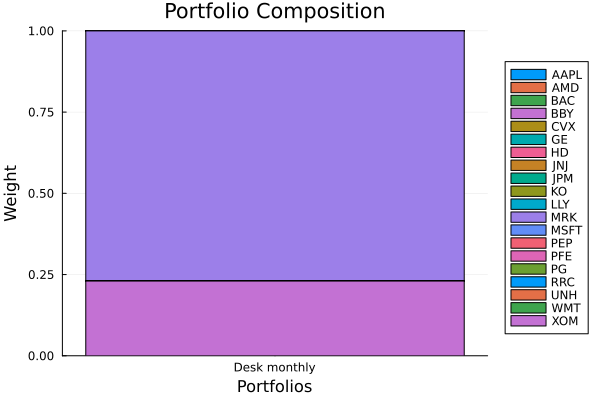

In [6]:
plot_stacked_bar_composition([desk], rd; xticks = (1:1, ["Desk monthly"]))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*